# 2. Why don't clouds fall?
## Introduction
In Chapter 2, we explored the question of why clouds do not fall. To answer this, we developed the following ODE model for the velocity, $v(t)$, of a single cloud particle:

$$ \frac{dv}{dt} = \frac{1}{\tau} (v_T(t) - v), $$

where $v_T(t)$ is the terminal velocity determined by the particle's mass and the forces acting on it (gravity, wind drag, etc.), while $\tau$ is the response time, which depends essentially on the particle size and air viscosity.

As we will see throughout the book, this equation appears in many different contexts. Therefore, the primary objective of the exercises in this notebook is to gain insight into its dynamic behavior. To this end, we rewrite the equation in a more general form:

$$ \dot{x} = \frac{f(t) - x}{\tau} $$

In this equation:
* $x(t)$ represents the system's state variable.
* $f(t)$ acts as a time-varying input or driving force.
* $\tau$ is a parameter representing the relaxation time of the system.

We will numerically solve this equation for various input functions $f(t)$, such as sinusoidal, square, and sawtooth waves. A key focus will be studying the influence of the parameter $\tau$. By varying $\tau$ relative to the characteristic timescales of $f(t)$, we can observe different dynamic regimes, ranging from the system closely tracking the input to acting as a low-pass filter that smooths out rapid fluctuations.



In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.signal import square, sawtooth

## Model Definitions
In the next cell, we define the differential equations for the different models to be studied. These functions represent the system dynamics for the various input functions $f(t)$ considered in the exercises.

In [11]:
def model(x, t, tau):
    return  (1 - x)/tau

def modelSin(x, t, tau):
    return  (np.sin(2*np.pi*t) - x)/tau

def modelSquare(x, t, tau):
    return  (square(2*np.pi*t) - x)/tau

def modelSawtooth(x, t, tau):
    return  (sawtooth(2*np.pi*t) - x)/tau

## Constant Input Case: $f(t) = 1$
We begin our investigation with the simplest case: a constant input function $f(t) = 1$.

In this section, we will:
* Verify Convergence: Simulate the system for various initial conditions $x_0$ to demonstrate that, regardless of the starting point, all trajectories converge to the steady state $x^* = 1$.
* Analyze the Role of $\tau$: Vary the relaxation time parameter $\tau$ to study its effect on the system's dynamics. We expect to observe that shorter values of $\tau$ result in faster convergence to the steady state, while larger values lead to a slower, more sluggish response.

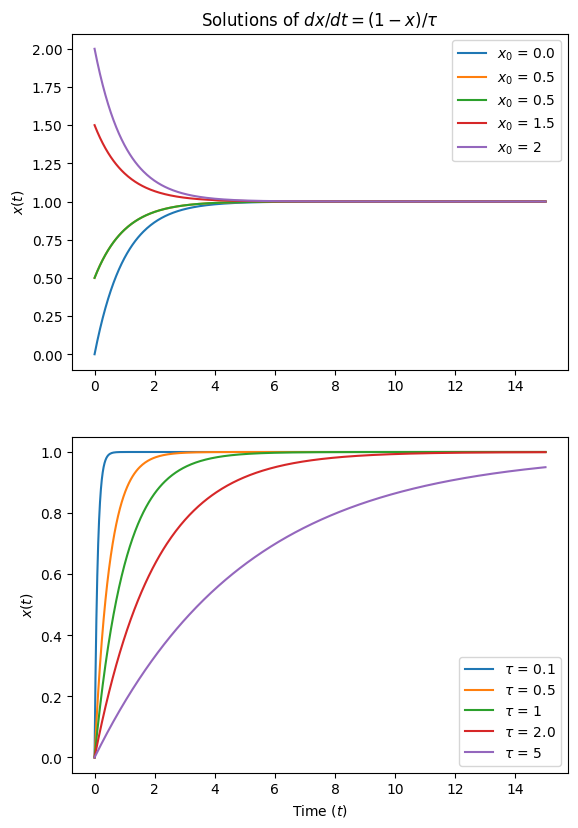

In [12]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(6.4, 9.6))

t = np.linspace(0, 15, 500)  # Time points

tau = 1  # Rate constant

x0 = 0.0     # Initial condition
x = odeint(model, x0, t, args=(tau,))
ax[0].plot(t, x, label=rf'$x_0$ = {x0}')

x0 = 0.5     # Initial condition
x = odeint(model, x0, t, args=(tau,))
ax[0].plot(t, x, label=rf'$x_0$ = {x0}')

x0 = 0.5     # Initial condition
x = odeint(model, x0, t, args=(tau,))
ax[0].plot(t, x, label=rf'$x_0$ = {x0}')

x0 = 1.5     # Initial condition
x = odeint(model, x0, t, args=(tau,))
ax[0].plot(t, x, label=rf'$x_0$ = {x0}')

x0 = 2     # Initial condition
x = odeint(model, x0, t, args=(tau,))
ax[0].plot(t, x, label=rf'$x_0$ = {x0}')

ax[0].set_title(r'Solutions of $dx/dt = (1 - x)/\tau$')
#ax[0].set_xlabel(r'Time ($t$)')
ax[0].set_ylabel(r'$x(t)$')
ax[0].legend()

x0 = 0.0     # Initial condition

tau = 0.1  # Rate constant
x = odeint(model, x0, t, args=(tau,))
ax[1].plot(t, x, label=rf'$\tau$ = {tau}')

tau = .5  # Rate constant
x = odeint(model, x0, t, args=(tau,))
ax[1].plot(t, x, label=rf'$\tau$ = {tau}')

tau = 1  # Rate constant
x = odeint(model, x0, t, args=(tau,))
ax[1].plot(t, x, label=rf'$\tau$ = {tau}')

tau = 2.0  # Rate constant
x = odeint(model, x0, t, args=(tau,))
ax[1].plot(t, x, label=rf'$\tau$ = {tau}')

tau = 5  # Rate constant
x = odeint(model, x0, t, args=(tau,))
ax[1].plot(t, x, label=rf'$\tau$ = {tau}')


#ax[1].set_title(r'Solution of $dx/dt = (1 - x)/\tau$')
ax[1].set_xlabel(r'Time ($t$)')
ax[1].set_ylabel(r'$x(t)$')
ax[1].legend()

## Sinusoidal Input: Analyzing the Effect of Relaxation Time ($\tau$)

For a sinusoidal input, $f(t) =\sin(t)$, we will analyze the effect of the relaxation time, $\tau$, on the system's response, $x(t)$. We expect that smaller values of $\tau$ will result in the output, $x(t)$, more closely tracking the input, $f(t)$.

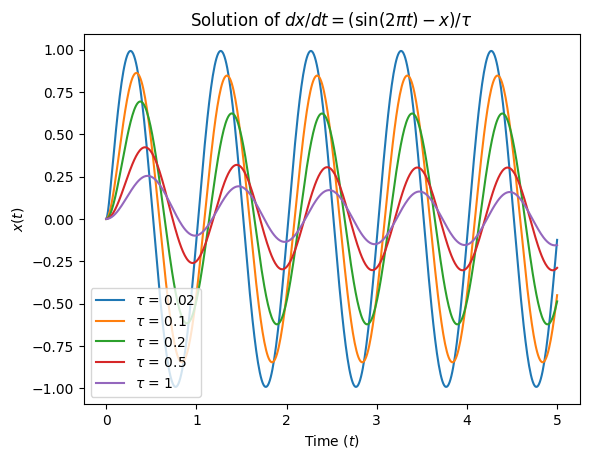

In [13]:
fig, ax = plt.subplots()

x0 = 0.0     # Initial condition
t = np.linspace(0, 5, 500)  # Time points


tau = 0.02  # Rate constant
x = odeint(modelSin, x0, t, args=(tau,))
ax.plot(t, x, label=rf'$\tau$ = {tau}')

tau = .1  # Rate constant
x = odeint(modelSin, x0, t, args=(tau,))
ax.plot(t, x, label=rf'$\tau$ = {tau}')
tau = .2  # Rate constant
x = odeint(modelSin, x0, t, args=(tau,))
ax.plot(t, x, label=rf'$\tau$ = {tau}')
tau = .5  # Rate constant
x = odeint(modelSin, x0, t, args=(tau,))
ax.plot(t, x, label=rf'$\tau$ = {tau}')
tau = 1  # Rate constant
x = odeint(modelSin, x0, t, args=(tau,))
ax.plot(t, x, label=rf'$\tau$ = {tau}')


ax.set_title(r'Solution of $dx/dt = (\sin(2\pi t) - x)/\tau$')
ax.set_xlabel(r'Time ($t$)')
ax.set_ylabel(r'$x(t)$')
ax.legend()

## Square-wave input

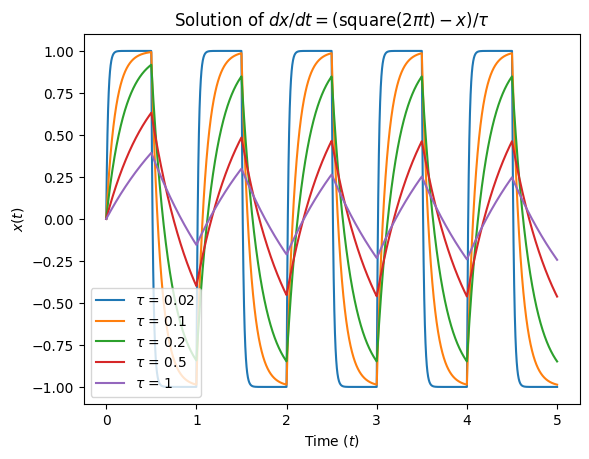

In [14]:
fig, ax = plt.subplots()

x0 = 0.0     # Initial condition
t = np.linspace(0, 5, 5000)  # Time points


tau = 0.02  # Rate constant
x = odeint(modelSquare, x0, t, args=(tau,))
ax.plot(t, x, label=rf'$\tau$ = {tau}')
tau = .1  # Rate constant
x = odeint(modelSquare, x0, t, args=(tau,))
ax.plot(t, x, label=rf'$\tau$ = {tau}')
tau = .2  # Rate constant
x = odeint(modelSquare, x0, t, args=(tau,))
ax.plot(t, x, label=rf'$\tau$ = {tau}')
tau = .5  # Rate constant
x = odeint(modelSquare, x0, t, args=(tau,))
ax.plot(t, x, label=rf'$\tau$ = {tau}')
tau = 1  # Rate constant
x = odeint(modelSquare, x0, t, args=(tau,))
ax.plot(t, x, label=rf'$\tau$ = {tau}')

ax.set_title(r'Solution of $dx/dt = (\text{square}(2\pi t) - x)/\tau$')
ax.set_xlabel(r'Time ($t$)')
ax.set_ylabel(r'$x(t)$')
ax.legend()

## Saw-tooth input

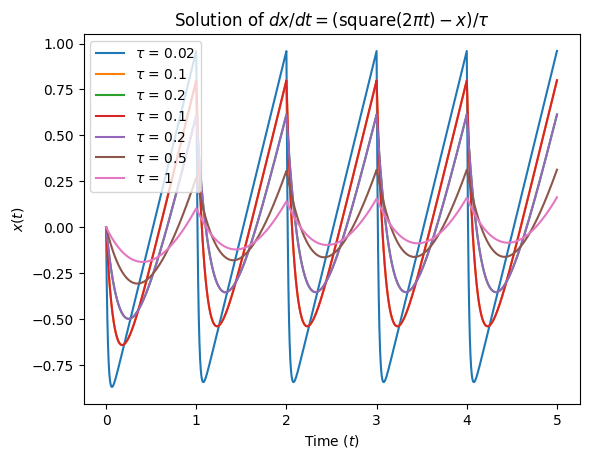

In [15]:
fig, ax = plt.subplots()

x0 = 0.0     # Initial condition
t = np.linspace(0, 5, 5000)  # Time points

tau = 0.02  # Rate constant
x = odeint(modelSawtooth, x0, t, args=(tau,))
ax.plot(t, x, label=rf'$\tau$ = {tau}')
tau = .1  # Rate constant
x = odeint(modelSawtooth, x0, t, args=(tau,))
ax.plot(t, x, label=rf'$\tau$ = {tau}')
tau = .2  # Rate constant
x = odeint(modelSawtooth, x0, t, args=(tau,))
ax.plot(t, x, label=rf'$\tau$ = {tau}')
tau = .1  # Rate constant
x = odeint(modelSawtooth, x0, t, args=(tau,))
ax.plot(t, x, label=rf'$\tau$ = {tau}')
tau = .2  # Rate constant
x = odeint(modelSawtooth, x0, t, args=(tau,))
ax.plot(t, x, label=rf'$\tau$ = {tau}')
tau = .5  # Rate constant
x = odeint(modelSawtooth, x0, t, args=(tau,))
ax.plot(t, x, label=rf'$\tau$ = {tau}')
tau = 1  # Rate constant
x = odeint(modelSawtooth, x0, t, args=(tau,))
ax.plot(t, x, label=rf'$\tau$ = {tau}')

ax.set_title(r'Solution of $dx/dt = (\text{square}(2\pi t) - x)/\tau$')
ax.set_xlabel(r'Time ($t$)')
ax.set_ylabel(r'$x(t)$')
ax.legend()


## Conclusions

The results above suggest that the differential equation $\dot{x} = (f(t) - x) / \tau$ models a low-pass filter with a cut-off frequency of $1/\tau$. If the system is viewed as an input-response system, $f(t)$ models the input function, while $x(t)$ corresponds to the response. Consequently, the ability of $x(t)$ to follow the input is determined by the relationship between the system response time $\tau$ and the characteristic timescale of the input, $T$ (which corresponds to the input period in the examples above). If $\tau \ll T$, $x(t)$ accurately follows the input. In the opposite case, the response is significantly attenuated.
